In [26]:
import numpy as np
import os
import xarray as xr
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pygmsh
import gmsh
import capytaine as cpt
from scipy.io import loadmat

import wecopttool as wot

In [27]:
# Frequency object
wavefreq    = 1/8 # Hz
f1          = wavefreq
nfreq       = 10
freq        = wot.frequency(f1, nfreq, False) # False -> no zero frequency

# Define waves object
amplitude   = 0.005 # m
phase       = 0 # degrees
wavedir     = 0 # degrees
waves       = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude, phase, wavedir)

In [28]:
# platform is a rectangle with cg at -0.46 and 1.44 m long, 0.76 m wide
flapThicknessBottom = 0.04
flapThicknessTop    = 0.1
flapCenterDistanceApart = 1.44
flapWidth   = 0.76
flapHeight = 0.58
flapDraft  = 0.59 # 0.53 is based on matching impedance, 0.59 for fully submerged
cgHeightAboveHinge = 0.17
flap1CG     = [-flapCenterDistanceApart/2, 0, -flapDraft+cgHeightAboveHinge] # from water surface/origin
flap2CG     = [flapCenterDistanceApart/2, 0, -flapDraft+cgHeightAboveHinge] # from water surface/origin

platformFrameLength      = 1.44 
platformFrameThickness = 0.05
platformFrameWidth = 1.06
platformFrameTopDepth = 0.53 + 0.1
platformCG      = [0, 0, -0.8]
cutoutWidth         = platformFrameWidth - 2*platformFrameThickness
cutoutLength        = platformFrameLength - 2*platformFrameThickness

fullWidth = 1.63
columnsRadius       = 0.1
columnsDraft        = 0.53 + 0.1 + 0.4
columnsXY           = [flapCenterDistanceApart/2, fullWidth/2-columnsRadius]

daqLength = 0.72
daqWidth = 0.6
daqHeight = 0.2
daqTopDepth = 0.53 + 0.1 + 0.05

#%% Define the meshes
# Define the meshes
with pygmsh.occ.Geometry() as geom:
    gmsh.option.setNumber('Mesh.MeshSizeFactor', 0.3)
    platform = geom.add_box([-platformFrameLength/2, -platformFrameWidth/2, -platformFrameTopDepth-platformFrameThickness], [platformFrameLength,platformFrameWidth,platformFrameThickness])
    cutout = geom.add_box([-cutoutLength/2, -cutoutWidth/2, -platformFrameTopDepth-platformFrameThickness], [cutoutLength,cutoutWidth,platformFrameThickness])
    cyl1 = geom.add_cylinder([-columnsXY[0], -columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl2 = geom.add_cylinder([-columnsXY[0], columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl3 = geom.add_cylinder([columnsXY[0], -columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl4 = geom.add_cylinder([columnsXY[0], columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    DAQ = geom.add_box([-daqLength/2, -daqWidth/2, -daqTopDepth-daqHeight], [daqLength,daqWidth,daqHeight])
    platformFrame = geom.boolean_difference(platform,cutout)
    geom.boolean_union([platformFrame,DAQ,cyl1,cyl2,cyl3,cyl4])
    platformMesh = geom.generate_mesh()

with pygmsh.geo.Geometry() as geom:
    flap1 = geom.add_polygon(
            [[-flapCenterDistanceApart/2 - flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [-flapCenterDistanceApart/2 + flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [-flapCenterDistanceApart/2 + flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft],
            [-flapCenterDistanceApart/2 - flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft]],mesh_size=0.1)
    geom.extrude(flap1,[0,flapWidth,0])
    flap1Mesh = geom.generate_mesh()

with pygmsh.geo.Geometry() as geom:
    flap2 = geom.add_polygon(
            [[flapCenterDistanceApart/2 - flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [flapCenterDistanceApart/2 + flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [flapCenterDistanceApart/2 + flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft],
            [flapCenterDistanceApart/2 - flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft]],mesh_size=0.1)
    geom.extrude(flap2,[0,flapWidth,0])
    flap2Mesh = geom.generate_mesh()


# define the floating body
m1 = 189.8
J1 = 30
# platform = cpt.FloatingBody(mesh=platformMesh, name=f'platform')
platform = cpt.FloatingBody(mesh=platformMesh, name=f'platform', center_of_mass=platformCG)
platform.add_all_rigid_body_dofs()
platform.rotation_center = platform.center_of_mass
# platform.inertia_matrix = platform.compute_rigid_body_inertia()
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([m1,m1,m1,J1,J1,J1]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(platform.dofs),
                                    'radiating_dof': list(platform.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
platform.inertia_matrix = rigid_inertia_matrix_xr
platform.hydrostatic_stiffness = platform.immersed_part().compute_hydrostatic_stiffness()

# define the floating body
flap1 = cpt.FloatingBody(mesh=flap1Mesh, name=f'flap1', center_of_mass=flap1CG)
flap1.add_all_rigid_body_dofs()
#flap1.show_matplotlib()
flap1.rotation_center = flap1.center_of_mass
m2 = 23.1
J2 = 1.19
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([m2,m2,m2,J2,J2,J2]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(flap1.dofs),
                                    'radiating_dof': list(flap1.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
flap1.inertia_matrix = rigid_inertia_matrix_xr
flap1.hydrostatic_stiffness = flap1.immersed_part().compute_hydrostatic_stiffness()

# define the floating body
flap2 = cpt.FloatingBody(mesh=flap2Mesh, name=f'flap2', center_of_mass=flap2CG)
flap2.add_all_rigid_body_dofs()
flap2.rotation_center = flap2.center_of_mass
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([m2,m2,m2,J2,J2,J2]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(flap2.dofs),
                                    'radiating_dof': list(flap2.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
flap2.inertia_matrix = rigid_inertia_matrix_xr
flap2.hydrostatic_stiffness = flap2.immersed_part().compute_hydrostatic_stiffness()

In [29]:
# run BEM calculations
bem_data_file = 'foswec_WOT.nc'

if os.path.exists(bem_data_file):
    bem_data = wot.read_netcdf(bem_data_file)
else:
    bem_data = wot.run_bem(platform+flap1+flap2, freq, depth=2)
    bem_data['radiating_dof'] = bem_data['radiating_dof'].astype(str)
    bem_data['influenced_dof'] = bem_data['influenced_dof'].astype(str)
    wot.write_netcdf(bem_data_file, bem_data) # saves BEM data to file

body_coord = bem_data.coords["body_name"].values
com = np.vstack([b.center_of_mass for b in [platform, flap1, flap2]])
cob = np.vstack([b.center_of_buoyancy for b in [platform, flap1, flap2]])
volumes = np.array([b.immersed_part().volume for b in [platform, flap1, flap2]], dtype=float)

bem_data["center_of_mass"] = xr.DataArray(com, dims=("bod","xyz"), coords={"body": body_coord, "xyz": ["x","y","z"]},attrs={"units": "m"})
bem_data["center_of_buoyancy"] = xr.DataArray(cob, dims=("bod","xyz"), coords={"body": body_coord, "xyz": ["x","y","z"]},attrs={"units": "m"})
bem_data["volume"] = xr.DataArray(volumes, dims=("bod",), coords={"body": body_coord}, attrs={"units": "m^3"})

In [30]:
import FOSWEC_M4E_inputs

# create multibody system for wavebot using M4E
m0 = [m1, m2, m2]
J0 = [J1, J2, J2]

# return the reduced coordinate matrices
impedance_reduced, excitation_reduced, hydrostatic_stiffness_reduced, R0, M4E_ndof = wot.utilities.setup_from_M4E(FOSWEC_M4E_inputs, bem_data, [platform, flap1, flap2], m0, J0)

Problem initialization finished in:		 0.000 seconds
All branches in the graph:
Branch 1: [1, 2]
Branch 2: [1, 3]
R and RD matrices calculation finished in:	 0.060 seconds
Symbolic EOM computation finished in:		 0.007 seconds
Compiling EOM expressions finished in:		 0.176 seconds

[Info] Updating float body 1 IC from (x=0.0, z=0.0) → (x=0.0, z=-0.8) relative to Reference_frame_Origin: (x=0, z=0) .


[HydroAdapter] Prepared bodies:
  [1] name='platform', CoM=[ 0.   0.  -0.8]
  [2] name='flap1', CoM=[-0.72  0.   -0.42]
  [3] name='flap2', CoM=[ 0.72  0.   -0.42]


In [31]:


# add forces to stabilize system
mooring_stiffness_full = np.diag([1e5, 1e5, 1e5, 0, 0, 0, 0, 0, 0])
mooring_stiffness = wot.utilities.reduce_damping_stiffness_M4E(mooring_stiffness_full, R0)

mooring_damping_full = np.diag([1e4, 1e4, 1e4, 0, 0, 0, 0, 0, 0])
mooring_damping = wot.utilities.reduce_damping_stiffness_M4E(mooring_damping_full, R0)

flap_linear_damping_full = np.diag([0, 0, 0, 0, 0, 100, 0, 0, 100])
flap_linear_damping = wot.utilities.reduce_damping_stiffness_M4E(flap_linear_damping_full, R0)

#########################################
# Solve using wec opt tool

def f_mooring(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    vel = jnp.dot(wec.derivative_mat,pos)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)

    mooring = -pos @ mooring_stiffness - vel @ mooring_damping
    mooring_force = jnp.dot(time_matrix,mooring)
    return mooring_force

def f_linear_damping(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    vel = jnp.dot(wec.derivative_mat,pos)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)

    damping = - vel @ flap_linear_damping
    linear_damping_force = jnp.dot(time_matrix, damping)
    return linear_damping_force

# WecOptTool does not take gravity into account and assumes equilibrium so no pretension needed
f_add = {'f_mooring': f_mooring, 'f_linear_damping': f_linear_damping} # 

# Define and solve the WOT object
wec = wot.WEC.from_impedance(
    waves.freq.values,
    impedance=impedance_reduced,
    exc_coeff=excitation_reduced,
    hydrostatic_stiffness=hydrostatic_stiffness_reduced,
    constraints=None,
    f_add=f_add,
)

# Objective function
obj_fun = lambda wec, x_wec, x_opt, waves : 0
nstate_opt = 0

# Solve
scale_x_wec = 1e1
scale_x_opt = 1e-3
scale_obj = 1e-2

results = wec.solve(
    waves,
    obj_fun,
    nstate_opt,
    scale_x_wec=scale_x_wec,
    scale_x_opt=scale_x_opt,
    scale_obj=scale_obj,
)

#%% Plot results
nsubsteps = 40
wec_fdom_full, wec_tdom_full = wot.utilities.post_process_M4E(wec, results, waves, nsubsteps, R0)

[14:20:32] WARNING  Real part of impedance for 1 has negative or close to zero terms. Shifting up elements [1] to a
                    minimum of  1e-06 N/(m/s)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.0
            Iterations: 1
            Function evaluations: 2
            Gradient evaluations: 1


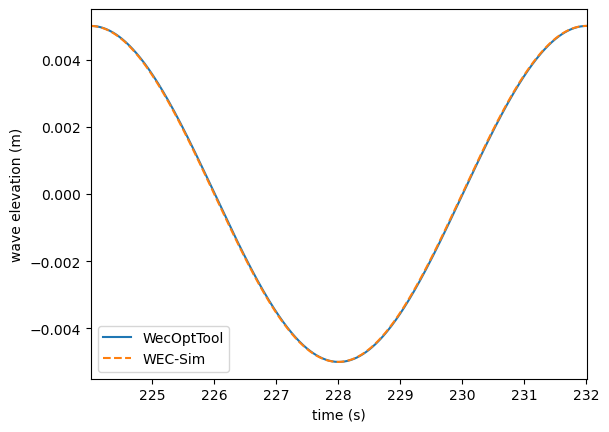

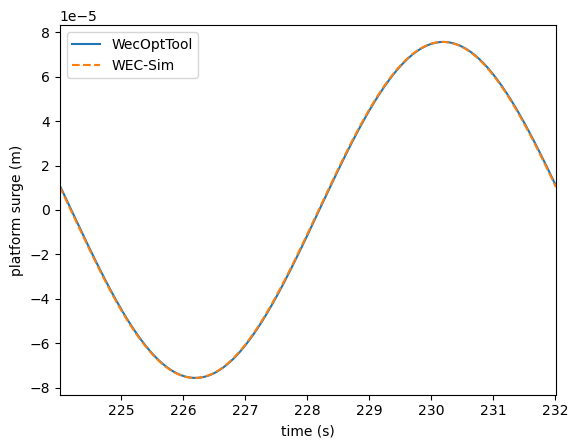

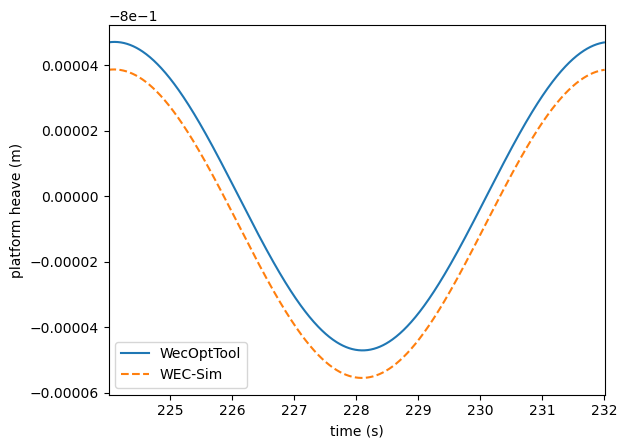

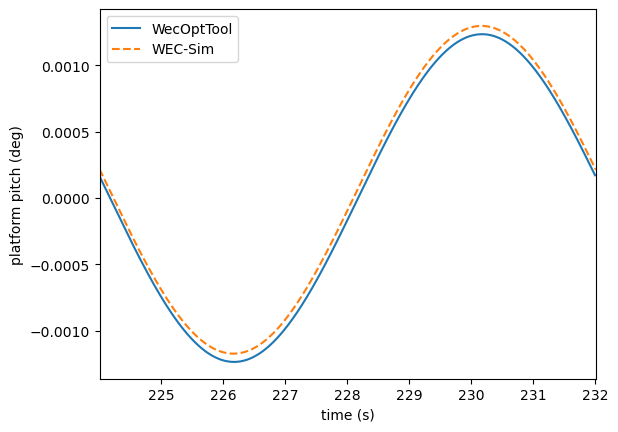

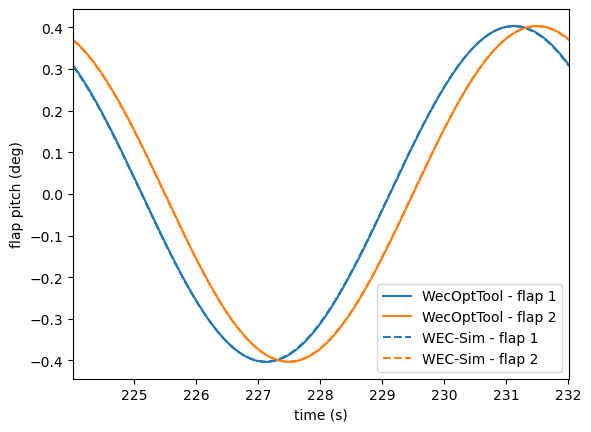

In [32]:
# load in WEC-Sim results for comparison

ws_path = 'WEC-Sim'
ws_output = loadmat(os.path.join(ws_path,'WSoutput_01.mat'), struct_as_record=False, squeeze_me=True)

phase_offset_time = 224.01

plt.figure()
plt.plot(wec_tdom_full['time']+phase_offset_time, np.squeeze(wec_tdom_full.sel(realization=0)['wave_elev']), label='WecOptTool')
plt.plot(ws_output['time'], ws_output['waveElev'], '--', label='WEC-Sim')
plt.xlabel('time (s)')
plt.ylabel('wave elevation (m)')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()

plt.figure()
plt.plot(wec_tdom_full['time']+phase_offset_time, wec_tdom_full.sel(realization=0).pos[0,:], label='WecOptTool')
plt.plot(ws_output['time'], ws_output['platformResponse'][:,0], '--', label='WEC-Sim')
plt.xlabel('time (s)')
plt.ylabel('platform surge (m)')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()

plt.figure()
plt.plot(wec_tdom_full['time']+phase_offset_time, wec_tdom_full.sel(realization=0).pos[1,:]+platformCG[2], label='WecOptTool')
plt.plot(ws_output['time'], ws_output['platformResponse'][:,2], '--', label='WEC-Sim')
plt.xlabel('time (s)')
plt.ylabel('platform heave (m)')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()

plt.figure()
plt.plot(wec_tdom_full['time']+phase_offset_time, wec_tdom_full.sel(realization=0).pos[2,:]*180/np.pi, label='WecOptTool')
plt.plot(ws_output['time'], ws_output['platformResponse'][:,4]*180/np.pi, '--', label='WEC-Sim')
plt.xlabel('time (s)')
plt.ylabel('platform pitch (deg)')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()

plt.figure()
plt.plot(wec_tdom_full['time']+phase_offset_time, wec_tdom_full.sel(realization=0).pos[5,:]*180/np.pi, color='C0', label='WecOptTool - flap 1')
plt.plot(wec_tdom_full['time']+phase_offset_time, wec_tdom_full.sel(realization=0).pos[8,:]*180/np.pi, color='C1', label='WecOptTool - flap 2')
plt.plot(ws_output['time'], ws_output['pto1Response'][:,4]*180/np.pi, '--', color='C0', label='WEC-Sim - flap 1')
plt.plot(ws_output['time'], ws_output['pto2Response'][:,4]*180/np.pi, '--', color='C1', label='WEC-Sim - flap 2')
plt.xlabel('time (s)')
plt.ylabel('flap pitch (deg)')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()


In [33]:
def rmse_over_timerange(t_std, y_std, t_cmp, y_cmp, t0, t1):
    """
    WEC-Sim is the standard: (t_std, y_std).
    Interpolate WecOptTool (t_cmp, y_cmp) onto t_std, then compute RMSE on [t0, t1].
    """
    t_std = np.asarray(t_std)
    y_std = np.asarray(y_std)
    t_cmp = np.asarray(t_cmp)
    y_cmp = np.asarray(y_cmp)

    mask = (t_std >= t0) & (t_std <= t1)
    tt = t_std[mask]
    y_true = y_std[mask]

    y_pred = np.interp(tt, t_cmp, y_cmp)
    max_ref                 = np.max(np.abs(y_true), axis=0) # Normalization factors from Gonzalez 2006
    rel_L2_per_DOF          = np.abs(y_pred - y_true) / max_ref
    NRMSE_per_DOF  = np.linalg.norm(rel_L2_per_DOF / len(tt), axis=0)
    #NRMSE_per_body          = np.linalg.norm(NRMSE_per_body_per_DOF,axis=-1)
    return NRMSE_per_DOF #np.sqrt(np.mean((y_pred - y_true)**2))

# time window (same as your plots)
t0 = phase_offset_time
t1 = phase_offset_time + 1/wavefreq - (wec_tdom_full["time"].values[1] - wec_tdom_full["time"].values[0]) # subtract one time step to avoid extrapolation in interpolation step below

# time vectors
t_ws  = ws_output["time"]                       # standard
t_wot = wec_tdom_full["time"] + phase_offset_time    # compared dataset (shifted like your plots)

# define the 5 comparisons: (name, WEC-Sim signal, WecOptTool signal)
comparisons = [
    ("platform surge",
     ws_output["platformResponse"][:, 0],
     wec_tdom_full.sel(realization=0).pos[0,:]),

    ("platform heave",
     ws_output["platformResponse"][:, 2],
     wec_tdom_full.sel(realization=0).pos[1,:] + platformCG[2]),

    ("platform pitch",
     ws_output["platformResponse"][:, 4] * 180/np.pi,
     wec_tdom_full.sel(realization=0).pos[2,:] * 180/np.pi),

    ("flap 1 pitch",
     ws_output["pto1Response"][:, 4] * 180/np.pi,
     wec_tdom_full.sel(realization=0).pos[5,:] * 180/np.pi),

    ("flap 2 pitch",
     ws_output["pto2Response"][:, 4] * 180/np.pi,
     wec_tdom_full.sel(realization=0).pos[8,:] * 180/np.pi),
]

# compute RMSEs (pure numpy)
names = [c[0] for c in comparisons]
rmses = np.array([
    rmse_over_timerange(t_ws, y_ws, t_wot, y_wot, t0, t1)
    for (_, y_ws, y_wot) in comparisons
])

# Option A: simple "table" as a dict of numpy arrays (no pandas)
rmse_table = {"variable": np.array(names, dtype=object), "rmse": rmses}
print("Normalized RMSE (%) over [{:.6g}, {:.6g}] s".format(t0, t1))
for n, e in zip(rmse_table["variable"], 100*rmse_table["rmse"]):
    print(f"{n:22s}  {e:.6g}")


Normalized RMSE (%) over [224.01, 232] s
platform surge          0.00878191
platform heave          1.66294e-05
platform pitch          0.0765435
flap 1 pitch            0.00695633
flap 2 pitch            0.00610777
